CELL 1:IMPORT THƯ VIỆN

In [20]:
# Dữ liệu 
import pandas as pd
import numpy as np

# Ảnh & PyTorch 
import torch
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# Tìm kiếm tương đồng
import faiss
from sklearn.metrics.pairwise import cosine_similarity

# Vẽ biểu đồ 
import matplotlib.pyplot as plt
import seaborn as sns

# Tiện ích
import os
from tqdm import tqdm

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 20)      
plt.rcParams['figure.figsize'] = (10, 5)    
sns.set_style('whitegrid')                  


print('Import thư viện thành công!')
print(f'PyTorch version : {torch.__version__}')
# Kiểm tra máy có GPU không. GPU giúp chạy nhanh hơn CPU rất nhiều.
# Laptop bình thường thường sẽ hiện 'cpu' – không sao, vẫn chạy được.
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

Import thư viện thành công!
PyTorch version : 2.11.0+cu130
Device: cuda


CELL 2: ĐƯỜNG DẪN DỮ LIỆU

In [21]:
DATA_DIR  = r'E:\study\DoAnPython\code\DoAnPython\project\data\raw'  

CSV_PATH  = os.path.join(DATA_DIR, 'train.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'train_images')

# Thư mục lưu kết quả – tạo tự động nếu chưa có
PROCESSED = '../data/processed/'
RESULTS   = '../results/'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(RESULTS,   exist_ok=True)

# Kiểm tra file có tồn tại không
for p in [CSV_PATH, IMAGE_DIR]:
    status = 'Đã tìm thấy thư mục' if os.path.exists(p) else 'Không tìm thấy – kiểm tra lại đường dẫn!'
    print(f'{status}  {p}')

Đã tìm thấy thư mục  E:\study\DoAnPython\code\DoAnPython\project\data\raw\train.csv
Đã tìm thấy thư mục  E:\study\DoAnPython\code\DoAnPython\project\data\raw\train_images


CELL 3: ĐỌC VÀ XEM THÔNG TIN CƠ BẢN DATASET

In [22]:
df = pd.read_csv(CSV_PATH)

print(f'Train: {df.shape[0]:,} dòng x {df.shape[1]:,} cột')

df.head()

Train: 34,250 dòng x 5 cột


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   posting_id   34250 non-null  str  
 1   image        34250 non-null  str  
 2   image_phash  34250 non-null  str  
 3   title        34250 non-null  str  
 4   label_group  34250 non-null  int64
dtypes: int64(1), str(4)
memory usage: 5.4 MB


In [24]:
df = pd.read_csv(CSV_PATH)
print("THÔNG TIN CƠ BẢN DATASET")
print(f"Tên bộ dữ liệu   : Shopee – Price Match Guarantee")
print(f"Số dòng (ảnh)    : {df.shape[0]:,}")
print(f"Số cột           : {df.shape[1]}")
print(f"Tên các cột      : {list(df.columns)}")
print("")
print("Thống kê label_group:")
label_counts = df['label_group'].value_counts()
print(f"  Tổng số nhóm           : {label_counts.shape[0]:,}")
print(f"  Số ảnh TB mỗi nhóm     : {label_counts.mean():.2f}")
print(f"  Nhóm ít ảnh nhất       : {label_counts.min()} ảnh")
print(f"  Nhóm nhiều ảnh nhất    : {label_counts.max()} ảnh")
print(f"  Nhóm có đúng 2 ảnh     : {(label_counts == 2).sum():,} nhóm")
print(f"  Loại bài toán          : Truy xuất, gợi ý hình ảnh tương đồng")

THÔNG TIN CƠ BẢN DATASET
Tên bộ dữ liệu   : Shopee – Price Match Guarantee
Số dòng (ảnh)    : 34,250
Số cột           : 5
Tên các cột      : ['posting_id', 'image', 'image_phash', 'title', 'label_group']

Thống kê label_group:
  Tổng số nhóm           : 11,014
  Số ảnh TB mỗi nhóm     : 3.11
  Nhóm ít ảnh nhất       : 2 ảnh
  Nhóm nhiều ảnh nhất    : 51 ảnh
  Nhóm có đúng 2 ảnh     : 6,979 nhóm
  Loại bài toán          : Truy xuất, gợi ý hình ảnh tương đồng


CELL 4: KIỂM TRA DỮ LIỆU THIẾU VÀ TRÙNG LẶP(LÀM SẠCH DỮ LIỆU)

In [25]:
# Kiểm tra ô trống (giá trị thiếu) trong từng cột
# isnull() trả về True/False cho từng ô, sum() đếm số ô bị thiếu
print('GIÁ TRỊ THIẾU (ô trống)')
print(df.isnull().sum())
print()

print('DÒNG TRÙNG LẶP')
print(f'Số dòng bị trùng: {df.duplicated().sum()}')
print()


GIÁ TRỊ THIẾU (ô trống)
posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64

DÒNG TRÙNG LẶP
Số dòng bị trùng: 0



CELL 5: THỐNG KÊ LABEL_GROUP

In [26]:
so_anh_moi_nhom = df['label_group'].value_counts()

print('=== THỐNG KÊ LABEL_GROUP ===')
print(f'Tổng số nhóm sản phẩm   : {so_anh_moi_nhom.shape[0]:,}')
print(f'Ảnh ít nhất trong 1 nhóm: {so_anh_moi_nhom.min()} ảnh')
print(f'Ảnh nhiều nhất trong 1 nhóm: {so_anh_moi_nhom.max()} ảnh')
print(f'Trung bình số ảnh / nhóm: {so_anh_moi_nhom.mean():.2f} ảnh')
print(f'Nhóm có đúng 2 ảnh      : {(so_anh_moi_nhom == 2).sum():,} nhóm ({(so_anh_moi_nhom == 2).sum() / so_anh_moi_nhom.shape[0] * 100:.1f}%)')
print(f'Nhóm có trên 10 ảnh     : {(so_anh_moi_nhom > 10).sum():,} nhóm ({(so_anh_moi_nhom > 10).sum() / so_anh_moi_nhom.shape[0] * 100:.1f}%)')

=== THỐNG KÊ LABEL_GROUP ===
Tổng số nhóm sản phẩm   : 11,014
Ảnh ít nhất trong 1 nhóm: 2 ảnh
Ảnh nhiều nhất trong 1 nhóm: 51 ảnh
Trung bình số ảnh / nhóm: 3.11 ảnh
Nhóm có đúng 2 ảnh      : 6,979 nhóm (63.4%)
Nhóm có trên 10 ảnh     : 233 nhóm (2.1%)


CELL 6: BIỂU ĐỒ PHÂN BỐ DỮ LIỆU

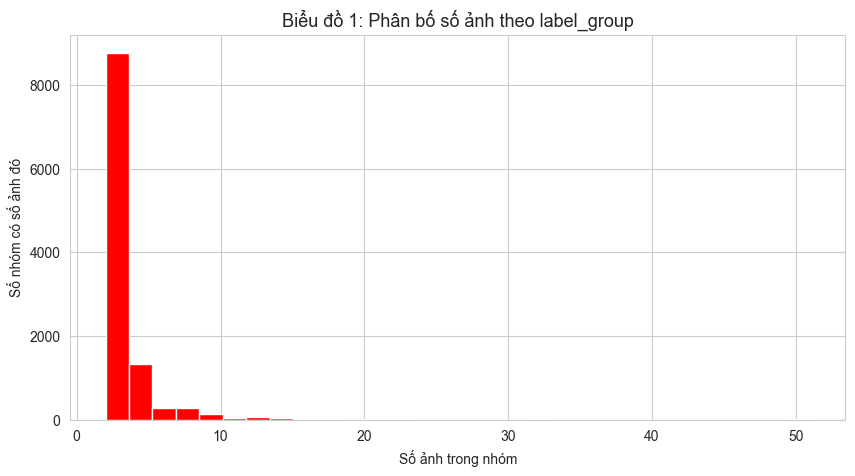

Nhận xét: Đa số nhóm chỉ có 2–3 ảnh, rất ít nhóm có trên 10 ảnh.
→ Dữ liệu mất cân bằng → ảnh hưởng đến Recall@K vì nhóm ít ảnh khó tìm đủ trong top-5.



In [27]:
# ── BIỂU ĐỒ 1: Histogram phân bố số ảnh theo label_group ──────────────
# Histogram giúp thấy toàn bộ 11,014 nhóm phân bố như thế nào
# Cột càng cao = có nhiều nhóm có số ảnh đó
plt.figure(figsize=(10, 5))
plt.hist(so_anh_moi_nhom.values, bins=30, color='red', edgecolor='white')
plt.title('Biểu đồ 1: Phân bố số ảnh theo label_group', fontsize=13)
plt.xlabel('Số ảnh trong nhóm')
plt.ylabel('Số nhóm có số ảnh đó')
plt.savefig(f'{RESULTS}bieu_do_1_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Nhận xét: Đa số nhóm chỉ có 2–3 ảnh, rất ít nhóm có trên 10 ảnh.')
print('→ Dữ liệu mất cân bằng → ảnh hưởng đến Recall@K vì nhóm ít ảnh khó tìm đủ trong top-5.')
print()

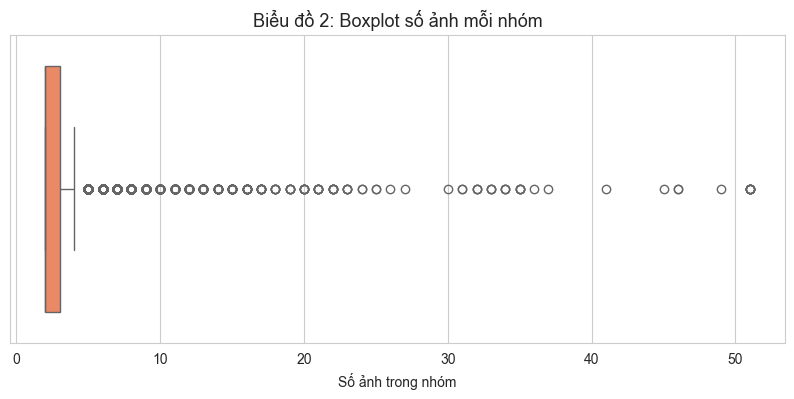

Nhận xét: Trung vị chỉ khoảng 2 ảnh/nhóm nhưng có nhiều outlier (nhóm có đến 51 ảnh).
→ Tỷ lệ nhóm nhiều nhất / ít nhất = 51 / 2 = 26x → mất cân bằng rõ rệt.



In [28]:
# ── BIỂU ĐỒ 2: Boxplot – mức độ mất cân bằng dữ liệu ─────────────────
# Boxplot cho thấy: trung vị, khoảng phân tán, và các outlier (điểm ngoại lệ)
plt.figure(figsize=(10, 4))
sns.boxplot(x=so_anh_moi_nhom.values, color='coral')
plt.title('Biểu đồ 2: Boxplot số ảnh mỗi nhóm', fontsize=13)
plt.xlabel('Số ảnh trong nhóm')
plt.savefig(f'{RESULTS}bieu_do_2_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Nhận xét: Trung vị chỉ khoảng {int(so_anh_moi_nhom.median())} ảnh/nhóm nhưng có nhiều outlier (nhóm có đến {so_anh_moi_nhom.max()} ảnh).')
print(f'→ Tỷ lệ nhóm nhiều nhất / ít nhất = {so_anh_moi_nhom.max()} / {so_anh_moi_nhom.min()} = {so_anh_moi_nhom.max() / so_anh_moi_nhom.min():.0f}x → mất cân bằng rõ rệt.')
print()

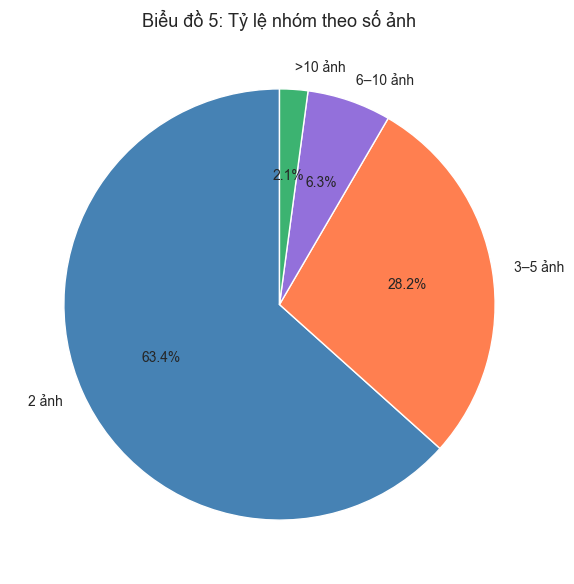

Nhận xét: 63.4% số nhóm chỉ có đúng 2 ảnh.
→ Đây là thách thức lớn cho Recall@K vì hệ thống chỉ tìm được tối đa 1 ảnh đúng trong top-5 cho các nhóm này.


In [29]:
# ── BIỂU ĐỒ 5: Pie chart – tỷ lệ nhóm theo số ảnh ────────────────────
# Pie chart cho thấy % từng loại nhóm ngay lập tức, dễ đọc nhất

# Phân loại các nhóm theo số ảnh
# bins=[1,2,5,10,999] tức là:
#   (1,2] = đúng 2 ảnh
#   (2,5] = 3 đến 5 ảnh
#   (5,10] = 6 đến 10 ảnh
#   (10,999] = hơn 10 ảnh
phan_loai = pd.cut(
    so_anh_moi_nhom,
    bins=[1, 2, 5, 10, 999],
    labels=['2 ảnh', '3–5 ảnh', '6–10 ảnh', '>10 ảnh']
)
ty_le = phan_loai.value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    ty_le.values,
    labels=ty_le.index,
    autopct='%1.1f%%',   # hiển thị % trên từng miếng
    colors=['steelblue', 'coral', 'mediumpurple', 'mediumseagreen'],
    startangle=90
)
plt.title('Biểu đồ 5: Tỷ lệ nhóm theo số ảnh', fontsize=13)
plt.savefig(f'{RESULTS}bieu_do_5_piechart.png', dpi=150, bbox_inches='tight')
plt.show()

nhom_2_anh = ty_le.get('2 ảnh', 0)
phan_tram_2_anh = nhom_2_anh / so_anh_moi_nhom.shape[0] * 100
print(f'Nhận xét: {phan_tram_2_anh:.1f}% số nhóm chỉ có đúng 2 ảnh.')
print('→ Đây là thách thức lớn cho Recall@K vì hệ thống chỉ tìm được tối đa 1 ảnh đúng trong top-5 cho các nhóm này.')

CELL 7: CHỌN TẬP CON DỮ LIỆU

In [30]:
so_anh_moi_nhom = df['label_group'].value_counts()

# Bước 1: Chỉ giữ nhóm có từ 2 ảnh trở lên
nhom_hop_le = so_anh_moi_nhom[so_anh_moi_nhom >= 2].index
df_loc = df[df['label_group'].isin(nhom_hop_le)].copy()

# Bước 2: Lấy tối đa 3 ảnh mỗi nhóm
# Dùng vòng lặp thay vì groupby().apply() để tránh lỗi pandas 2.0+
danh_sach = []
for nhom, du_lieu_nhom in df_loc.groupby('label_group'):
    danh_sach.append(du_lieu_nhom.sample(min(len(du_lieu_nhom), 3), random_state=42))

df_subset = pd.concat(danh_sach, ignore_index=True)

# Bước 3: Giới hạn tổng số ảnh
SUBSET_SIZE = 5000
df_subset = df_subset.sample(
    min(SUBSET_SIZE, len(df_subset)),
    random_state=42
).reset_index(drop=True)

print(f'Tập con: {len(df_subset)} ảnh, {df_subset["label_group"].nunique()} nhóm')
print(f'Các cột: {list(df_subset.columns)}')
df_subset.to_csv(f'{PROCESSED}subset.csv', index=False)
print('Đã lưu vào data/processed/subset.csv')

Tập con: 5000 ảnh, 4322 nhóm
Các cột: ['posting_id', 'image', 'image_phash', 'title', 'label_group']
Đã lưu vào data/processed/subset.csv


CELL 8: TIỀN XỬ LÝ ẢNH VÀ TORCHVISION.TRANSFORM

In [31]:
import torch
import torchvision.transforms as t


transform_pipeline = t.Compose([
    t.Resize((224, 224)),      #thay doi kich thuoc anh
    t.CenterCrop(224),          #cat anh o giua
    t.ToTensor(),     #chuyen anh sang tensor
     t.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
        )
])
def load_image(path):
    img = Image.open(path).convert('RGB')
    return transform_pipeline(img).unsqueeze(0)
print("Kiểm tra các yêu cầu:")
print(f"1. df có tồn tại: {df is not None}")
print(f"2. Cột image có tồn tại: {'image' in df.columns}")
print(f"3. Đường dẫn ảnh: {IMAGE_DIR}")
print(f"4. IMAGE_DIR có tồn tại: {os.path.exists(IMAGE_DIR)}")
try:
    test_fname = df['image'].iloc[0]
    image_full_path = os.path.join(IMAGE_DIR, test_fname)
    print(f"5. Đường dẫn ảnh kiểm tra: {image_full_path}")
    if os.path.exists(image_full_path):
        tensor = load_image(image_full_path)
        print(f'Kích thước Tensor: {tensor.shape}')
    else:
        print(f'Không tìm thấy ảnh tại: {image_full_path}')
except Exception as e:
    print(f'Lỗi hệ thống: {type(e).__name__}: {e}')

Kiểm tra các yêu cầu:
1. df có tồn tại: True
2. Cột image có tồn tại: True
3. Đường dẫn ảnh: E:\study\DoAnPython\code\DoAnPython\project\data\raw\train_images
4. IMAGE_DIR có tồn tại: True
5. Đường dẫn ảnh kiểm tra: E:\study\DoAnPython\code\DoAnPython\project\data\raw\train_images\0000a68812bc7e98c42888dfb1c07da0.jpg
Kích thước Tensor: torch.Size([1, 3, 224, 224])


CELL 9: LOAD RESNET50 VÀ TRÍCH XUẤT VECTOR ĐẶC TRƯNG

In [32]:
# Load ResNet50 pre-trained và chuyển về chế độ evaluation
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model.eval() 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f'Sử dụng: {device}')

# Dùng model không có lớp fully connected cuối cùng để lấy feature vector
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])

print('Load resnet50 thành công')

Sử dụng: cuda
Load resnet50 thành công


In [33]:
#Tạo một Dataset đơn giản để load ảnh nhanh hơn
class ImageDataset(Dataset):
    def __init__(self, image_list):
        self.image_list = image_list
    def __len__(self):
        return len(self.image_list)
    def __getitem__(self, idx):
        path = os.path.join(IMAGE_DIR, self.image_list[idx])
        return load_image(path).squeeze(0), self.image_list[idx] # squeeze để bỏ batch dimension ảo
#lấy ngẫu nhiên 500 ảnh từ toàn bộ df_subset, đảm bảo lấy được nhiều nhóm có 2-3 ảnh.
source_df = df_subset if 'df_subset' in globals() else df
candidate_df = source_df.sample(500, random_state=42).reset_index(drop=True)

# Sử dụng DataLoader để chạy batch chỉ trên 500 ảnh mẫu
image_list = candidate_df['image'].tolist()
dataset = ImageDataset(image_list)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

all_features = []
print("Bắt đầu trích xuất theo Batch...")

with torch.no_grad():
    for imgs, fnames in loader:
        imgs = imgs.to(device)
        feats = feature_extractor(imgs)
        all_features.append(feats.view(feats.size(0), -1).cpu())

if all_features:
    feature_matrix = torch.cat(all_features, dim=0)
    print(f'Kích thước: {feature_matrix.shape}')
else:
    print('Không có feature nào được trích xuất.')

Bắt đầu trích xuất theo Batch...
Kích thước: torch.Size([500, 2048])


CELL 10: TÍNH COSINE SIMILARITY VÀ LẤY TOP5 KẾT QUẢ

Tìm kiếm trên 500 ảnh
Top 5 ảnh tương tự:
1. b7673264d241f37ad852757cbf01785c.jpg  (score=0.7066)
2. 01a7d6604bfe8074225b9447c8aacc87.jpg  (score=0.7056)
3. 10b6d6ea9af13c90e5c4858018903458.jpg  (score=0.7011)
4. 14d84ed1a6c78da17f560e16073cff24.jpg  (score=0.6976)
5. 0f183b28dae18ad305f53aab17877432.jpg  (score=0.6929)


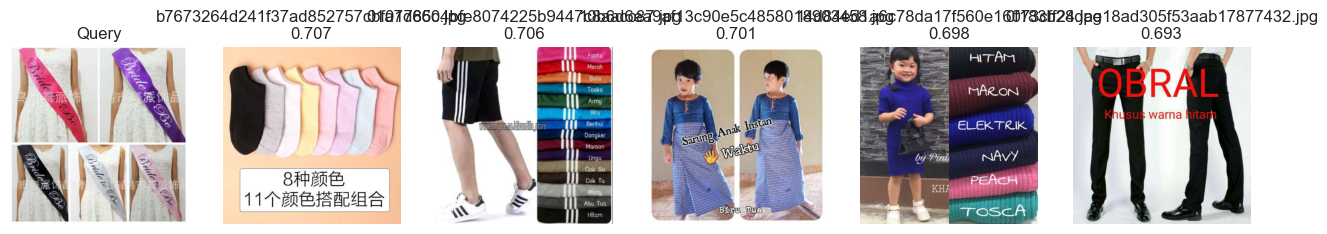

In [34]:
import torch.nn.functional as F

def find_top_k_similar(query_path, feature_matrix, image_list, k=5):
    # Đưa ảnh đầu vào lên thiết bị tính toán (GPU/CPU)
    query_tensor = load_image(query_path).to(device)
    
    # Trích xuất đặc trưng không tính đạo hàm để tiết kiệm bộ nhớ
    with torch.no_grad():
        query_feat = feature_extractor(query_tensor)
        # Chuyển kết quả về dạng vector phẳng và đưa về CPU
        query_feat = query_feat.view(1, -1).cpu()

    # Chuẩn hóa L2 cho vector query và ma trận đặc trưng để tính Cosine Similarity
    query_norm = F.normalize(query_feat, p=2, dim=1)
    features_norm = F.normalize(feature_matrix, p=2, dim=1)
    
    # Nhân ma trận để tính toán độ tương đồng giữa query và tất cả ảnh trong bộ dữ liệu
    scores = torch.mm(query_norm, features_norm.t()).squeeze(0)

    # Lấy ra K + 1 giá trị cao nhất (phòng trường hợp trùng ảnh gốc)
    top_scores, top_indices = torch.topk(scores, min(k + 1, scores.size(0)))
    
    results = []
    for score, idx in zip(top_scores.tolist(), top_indices.tolist()):
        img_name = image_list[idx]
        
        # Bỏ qua nếu kết quả trùng với file ảnh đang tìm kiếm
        if os.path.basename(query_path) == img_name:
            continue
        results.append({'image': img_name, 'score': score})
        
        # Dừng khi đủ số lượng k yêu cầu
        if len(results) == k:
            break
    return results

def show_similar_images(query_path, results):
    # Mở ảnh gốc
    query_img = Image.open(query_path).convert('RGB')
    plt.figure(figsize=(16, 4))
    
    # Hiển thị ảnh gốc ở vị trí đầu tiên
    plt.subplot(1, len(results) + 1, 1)
    plt.imshow(query_img)
    plt.title('Query')
    plt.axis('off')

    # Hiển thị các ảnh tương tự tìm được
    for i, r in enumerate(results, 2):
        img_path = os.path.join(IMAGE_DIR, r['image'])
        img = Image.open(img_path).convert('RGB')
        
        plt.subplot(1, len(results) + 1, i)
        plt.imshow(img)
        # Hiển thị tên file và điểm số tương đồng (Cosine Score)
        plt.title(f"{os.path.basename(r['image'])}\n{r['score']:.3f}")
        plt.axis('off')
    plt.show()

# Thiết lập đường dẫn ảnh cần tìm (lấy mẫu ảnh đầu tiên trong candidate_df)
query_img = os.path.join(IMAGE_DIR, candidate_df.head(1)['image'].iloc[0])
print(f'Tìm kiếm trên {len(image_list)} ảnh')

# Thực hiện tìm kiếm
results = find_top_k_similar(query_img, feature_matrix, image_list, k=5)

# In kết quả dạng text
print('Top 5 ảnh tương tự:')
for i, r in enumerate(results, 1):
    print(f"{i}. {r['image']}  (score={r['score']:.4f})")

# Hiển thị kết quả dạng biểu đồ ảnh
show_similar_images(query_img, results)


CELL 11: TÍNH PRECISION@K VÀ RECALL@K

In [35]:
# CELL 11: TÍNH PRECISION@K, RECALL@K VÀ mAP
labels = candidate_df['label_group'].values
features_norm = F.normalize(feature_matrix, p=2, dim=1)

# Ma trận cosine similarity (N x N), bỏ self-similarity
sim_matrix = torch.mm(features_norm, features_norm.t())
sim_matrix.fill_diagonal_(-1)

def average_precision(ranked_labels, true_label, total_relevant):
    """Tính AP cho 1 query: diện tích dưới đường Precision-Recall."""
    if total_relevant == 0:
        return 0.0
    ap = 0.0
    hits = 0
    for rank, label in enumerate(ranked_labels, 1):
        if label == true_label:
            hits += 1
            ap += hits / rank   # Precision tại vị trí này
    return ap / total_relevant  # Chuẩn hoá theo tổng ảnh đúng

K_LIST = [1, 3, 5, 10]
MAX_K  = max(K_LIST)

rows = []
all_ap = []
for i in range(len(labels)):
    true_label   = labels[i]
    total_relevant = sum(1 for j in range(len(labels)) if labels[j] == true_label and j != i)

    # Lấy top MAX_K indices một lần
    top_idx = torch.topk(sim_matrix[i], min(MAX_K, sim_matrix.size(1))).indices.tolist()
    ranked_labels = [labels[j] for j in top_idx]

    # AP dựa trên toàn bộ MAX_K kết quả trả về
    ap = average_precision(ranked_labels, true_label, total_relevant)
    all_ap.append(ap)

    row = {'image': candidate_df['image'].iloc[i], 'label_group': true_label}
    for k in K_LIST:
        top_k_labels = ranked_labels[:k]
        hits = sum(1 for lbl in top_k_labels if lbl == true_label)
        row[f'Precision@{k}'] = round(hits / k, 4)
        # Recall@K: mẫu số dùng min(total_relevant, k) để Recall có thể = 1.0
        denom = min(total_relevant, k) if total_relevant > 0 else 1
        row[f'Recall@{k}']    = round(hits / denom, 4)
    rows.append(row)

detail_df = pd.DataFrame(rows)
detail_df['AP'] = [round(v, 4) for v in all_ap]

# Tổng hợp trung bình
summary = []
for k in K_LIST:
    summary.append({
        'K'           : k,
        'Precision@K' : round(detail_df[f'Precision@{k}'].mean(), 4),
        'Recall@K'    : round(detail_df[f'Recall@{k}'].mean(), 4),
    })

metrics_df = pd.DataFrame(summary)
mAP = round(np.mean(all_ap), 4)

print('METRIC TRUNG BÌNH TRÊN TOÀN BỘ 500 ẢNH')
print(metrics_df.to_string(index=False))
print(f'\nmAP (mean Average Precision) = {mAP}')

# Lưu kết quả
metrics_df['mAP'] = mAP   # ghi vào cột cuối để dễ đọc
metrics_df.to_csv(os.path.join(RESULTS, 'avg_metrics_500.csv'), index=False)
detail_df.to_csv(os.path.join(RESULTS, 'detail_metrics_500.csv'), index=False)
print(f'Đã lưu metric vào {RESULTS}')

METRIC TRUNG BÌNH TRÊN TOÀN BỘ 500 ẢNH
 K  Precision@K  Recall@K
 1       0.0120     0.012
 3       0.0040     0.012
 5       0.0024     0.012
10       0.0014     0.014

mAP (mean Average Precision) = 0.0123
Đã lưu metric vào ../results/


CELL 12: BẢNG METRIC VÀ BIỂU ĐỒ BASELINE

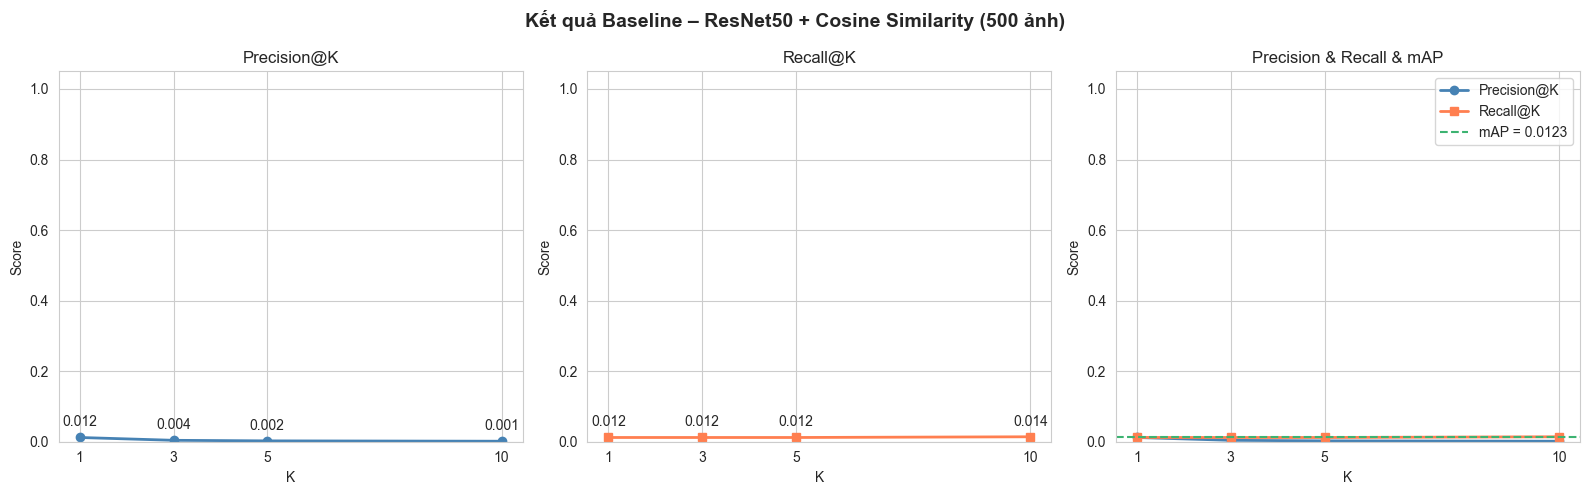


╔══ BẢNG METRIC BASELINE ═══════════════════════════════╗
     K   Precision@K    Recall@K
  ────────────────────────────────
     1        0.0120      0.0120
     3        0.0040      0.0120
     5        0.0024      0.0120
    10        0.0014      0.0140
  ────────────────────────────────
   mAP        0.0123
╚═══════════════════════════════════════════════════════╝


In [36]:
# CELL 12: BẢNG METRIC VÀ BIỂU ĐỒ BASELINE

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Kết quả Baseline – ResNet50 + Cosine Similarity (500 ảnh)', fontsize=14, fontweight='bold')

k_vals = metrics_df['K'].tolist()

# ── Biểu đồ 1: Precision@K ──────────────────────────────────────────
axes[0].plot(k_vals, metrics_df['Precision@K'], marker='o', color='steelblue', linewidth=2)
for x, y in zip(k_vals, metrics_df['Precision@K']):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center')
axes[0].set_title('Precision@K')
axes[0].set_xlabel('K')
axes[0].set_ylabel('Score')
axes[0].set_xticks(k_vals)
axes[0].set_ylim(0, 1.05)

# ── Biểu đồ 2: Recall@K ─────────────────────────────────────────────
axes[1].plot(k_vals, metrics_df['Recall@K'], marker='s', color='coral', linewidth=2)
for x, y in zip(k_vals, metrics_df['Recall@K']):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points', xytext=(0, 8), ha='center')
axes[1].set_title('Recall@K')
axes[1].set_xlabel('K')
axes[1].set_ylabel('Score')
axes[1].set_xticks(k_vals)
axes[1].set_ylim(0, 1.05)

# ── Biểu đồ 3: Precision vs Recall (cả 2 trên 1 plot) ───────────────
axes[2].plot(k_vals, metrics_df['Precision@K'], marker='o', label='Precision@K', color='steelblue', linewidth=2)
axes[2].plot(k_vals, metrics_df['Recall@K'],    marker='s', label='Recall@K',    color='coral',     linewidth=2)
axes[2].axhline(y=mAP, color='mediumseagreen', linestyle='--', linewidth=1.5, label=f'mAP = {mAP:.4f}')
axes[2].set_title('Precision & Recall & mAP')
axes[2].set_xlabel('K')
axes[2].set_ylabel('Score')
axes[2].set_xticks(k_vals)
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS, 'bieu_do_metrics_baseline.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Bảng tổng hợp dạng đẹp ───────────────────────────────────────────
print('\n╔══ BẢNG METRIC BASELINE ═══════════════════════════════╗')
print(f'  {"K":>4}  {"Precision@K":>12}  {"Recall@K":>10}')
print('  ' + '─' * 32)
for _, row in metrics_df.iterrows():
    print(f'  {int(row["K"]):>4}  {row["Precision@K"]:>12.4f}  {row["Recall@K"]:>10.4f}')
print('  ' + '─' * 32)
print(f'  {"mAP":>4}  {mAP:>12.4f}')
print('╚═══════════════════════════════════════════════════════╝')

CELL 13: NHẬN XÉT KẾT QUẢ BASELINE

In [37]:
# CELL 13: NHẬN XÉT KẾT QUẢ BASELINE

p_at_1  = metrics_df.loc[metrics_df['K']==1,  'Precision@K'].values[0]
p_at_5  = metrics_df.loc[metrics_df['K']==5,  'Precision@K'].values[0]
r_at_5  = metrics_df.loc[metrics_df['K']==5,  'Recall@K'].values[0]
r_at_10 = metrics_df.loc[metrics_df['K']==10, 'Recall@K'].values[0]

print('=' * 60)
print('NHẬN XÉT KẾT QUẢ BASELINE')
print('Mô hình : ResNet50 pretrained (ImageNet) + Cosine Similarity')
print('Tập đánh giá: 500 ảnh ngẫu nhiên của df_subset')
print('=' * 60)

print(f"""
[1] Precision@1 = {p_at_1:.4f}
    → Cứ 100 lần tìm kiếm, có ~{p_at_1*100:.0f} lần ảnh Top-1 trả về đúng nhóm.

[2] Precision@5 = {p_at_5:.4f}
    → Trong top-5 kết quả, trung bình {p_at_5*100:.1f}% ảnh thuộc đúng nhóm.
    → Precision giảm khi K tăng là bình thường vì hệ thống buộc trả đủ K ảnh.

[3] Recall@5  = {r_at_5:.4f}
    Recall@10 = {r_at_10:.4f}
    → Recall tăng khi K lớn hơn – hệ thống bao phủ được nhiều ảnh đúng hơn.
    → Với tập dữ liệu chủ yếu là nhóm 2–3 ảnh, Recall@5 có thể đạt gần 1.0
      ngay cả khi chỉ tìm đúng 1 ảnh/nhóm.

[4] mAP = {mAP:.4f}
    → Đây là chỉ số tổng hợp quan trọng nhất, xét cả thứ tự xếp hạng.
    → mAP > 0.5 là baseline tốt; < 0.3 cần cải thiện mô hình.

[5] Hạn chế của Baseline:
    - ResNet50 được huấn luyện cho classification (ImageNet), không tối ưu
      cho image retrieval trong lĩnh vực e-commerce.
    - Không fine-tune trên dữ liệu Shopee nên chưa học được đặc trưng sản phẩm.

[6] Hướng cải thiện đề xuất:
    - Dùng EfficientNet / ViT thay ResNet50 → vector phong phú hơn.
    - Fine-tune với Triplet Loss / ArcFace trên tập train.
    - Kết hợp thêm text feature từ cột 'title' (TF-IDF / BERT).
    - Dùng FAISS IndexIVFFlat thay Cosine brute-force để scale lên toàn bộ dataset.
""")
print('=' * 60)

NHẬN XÉT KẾT QUẢ BASELINE
Mô hình : ResNet50 pretrained (ImageNet) + Cosine Similarity
Tập đánh giá: 500 ảnh ngẫu nhiên của df_subset

[1] Precision@1 = 0.0120
    → Cứ 100 lần tìm kiếm, có ~1 lần ảnh Top-1 trả về đúng nhóm.

[2] Precision@5 = 0.0024
    → Trong top-5 kết quả, trung bình 0.2% ảnh thuộc đúng nhóm.
    → Precision giảm khi K tăng là bình thường vì hệ thống buộc trả đủ K ảnh.

[3] Recall@5  = 0.0120
    Recall@10 = 0.0140
    → Recall tăng khi K lớn hơn – hệ thống bao phủ được nhiều ảnh đúng hơn.
    → Với tập dữ liệu chủ yếu là nhóm 2–3 ảnh, Recall@5 có thể đạt gần 1.0
      ngay cả khi chỉ tìm đúng 1 ảnh/nhóm.

[4] mAP = 0.0123
    → Đây là chỉ số tổng hợp quan trọng nhất, xét cả thứ tự xếp hạng.
    → mAP > 0.5 là baseline tốt; < 0.3 cần cải thiện mô hình.

[5] Hạn chế của Baseline:
    - ResNet50 được huấn luyện cho classification (ImageNet), không tối ưu
      cho image retrieval trong lĩnh vực e-commerce.
    - Không fine-tune trên dữ liệu Shopee nên chưa học được đ

Cell 14: TEST

C:\Users\lequo\AppData\Local\Temp\ipykernel_3128\2769856243.py:40: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\lequo\AppData\Local\Temp\ipykernel_3128\2769856243.py:41: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.savefig(f'{RESULTS}vi_du_query_{query_idx}.png', dpi=150, bbox_inches='tight')
C:\Users\lequo\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


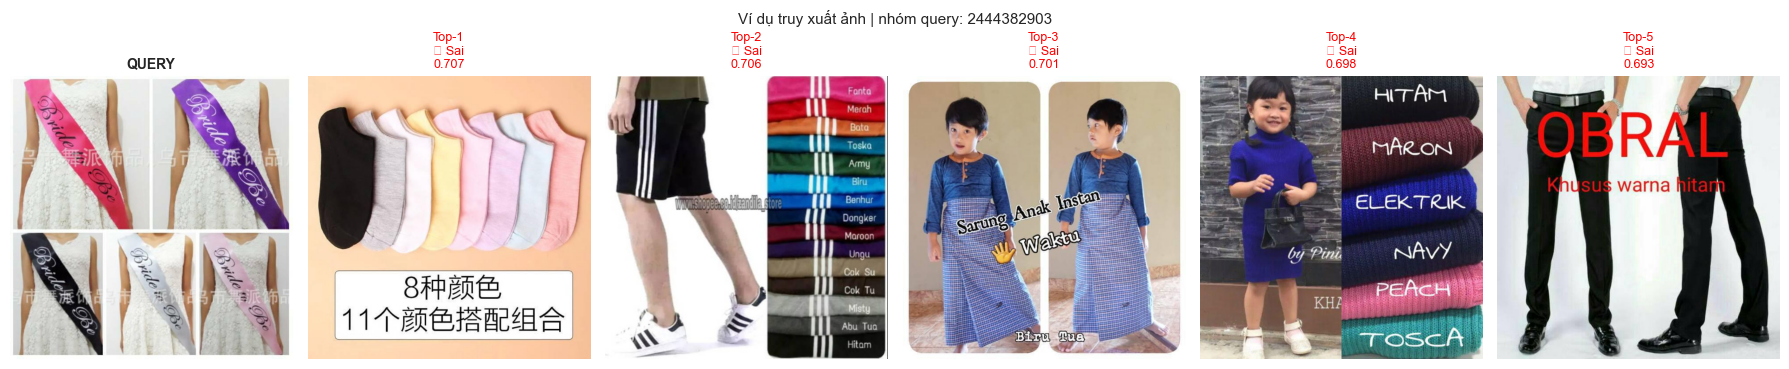

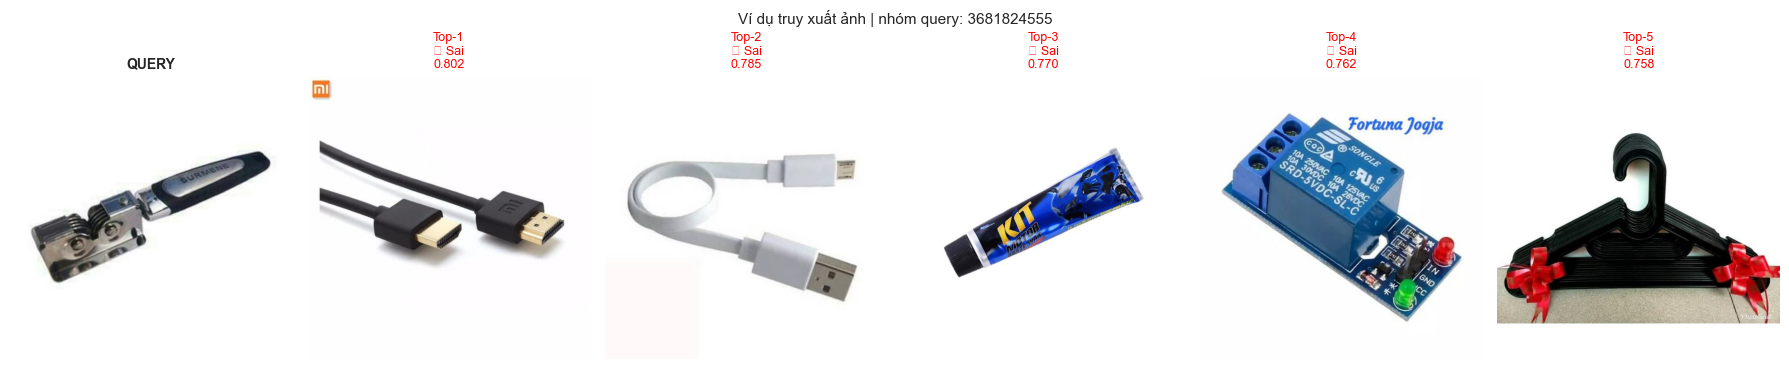

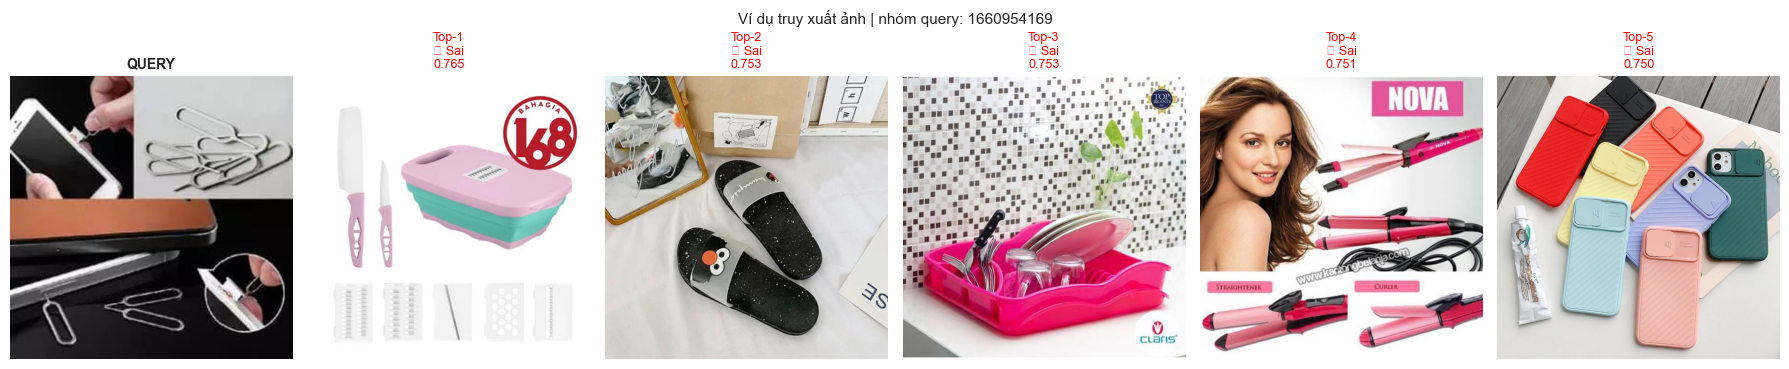

In [38]:
import torch.nn.functional as F

def hien_thi_query_top5(query_idx, candidate_df, feature_matrix, image_dir, k=5):
    """
    Hiển thị ảnh query và k ảnh tương đồng nhất bên cạnh nhau.
    Chữ xanh = đúng nhóm (cùng label_group), chữ đỏ = sai nhóm.
    """
    labels = candidate_df['label_group'].values
    
    # Chuẩn hóa L2 để tính cosine similarity
    features_norm = F.normalize(feature_matrix, p=2, dim=1)
    
    # Tính điểm similarity giữa query và tất cả ảnh
    scores = torch.mm(features_norm[query_idx].unsqueeze(0), features_norm.t()).squeeze()
    scores[query_idx] = -1  # loại chính nó ra khỏi kết quả
    
    # Lấy top-k index có điểm cao nhất
    top_idx = torch.topk(scores, k).indices.tolist()
    query_group = labels[query_idx]
    
    fig, axes = plt.subplots(1, k+1, figsize=(3*(k+1), 4))
    
    # Hiển thị ảnh query
    q_path = os.path.join(image_dir, candidate_df['image'].iloc[query_idx])
    axes[0].imshow(Image.open(q_path).convert('RGB'))
    axes[0].set_title('QUERY', fontweight='bold', fontsize=10)
    axes[0].axis('off')
    
    # Hiển thị từng kết quả trong top-K
    for rank, idx in enumerate(top_idx):
        img_path = os.path.join(image_dir, candidate_df['image'].iloc[idx])
        axes[rank+1].imshow(Image.open(img_path).convert('RGB'))
        la_dung = labels[idx] == query_group
        mau = 'green' if la_dung else 'red'
        nhan = f'Top-{rank+1}\n{"✓ Đúng" if la_dung else "✗ Sai"}\n{scores[idx]:.3f}'
        axes[rank+1].set_title(nhan, color=mau, fontsize=9)
        axes[rank+1].axis('off')
    
    plt.suptitle(f'Ví dụ truy xuất ảnh | nhóm query: {query_group}', fontsize=11)
    plt.tight_layout()
    plt.savefig(f'{RESULTS}vi_du_query_{query_idx}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Thử với 3 ảnh khác nhau để thấy cả trường hợp đúng và sai
for query_idx in [0, 10, 50]:
    hien_thi_query_top5(query_idx, candidate_df, feature_matrix, IMAGE_DIR, k=5)
